<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Decision_Tree_FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# General Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.base import clone

# Scikit-learn: Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    make_scorer
)
from sklearn import tree

# Imbalanced-learn: Oversampling
from imblearn.over_sampling import SMOTE

# Data Preprocessing

In [3]:
# Load CSV
file_path = '/content/drive/MyDrive/Customer_Churn_Data.csv'
data = pd.read_csv(file_path)

# Make a copy of the original dataset to work with
data_copy = data.copy()
df_dt = data_copy

# Check dataset
df_dt.head()
df_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Datatype Conversion

In [4]:
# Convert TotalCharges to numeric
df_dt['TotalCharges_numeric'] = pd.to_numeric(df_dt['TotalCharges'], errors='coerce')

# Check how many missing values after conversion
print("Missing values in TotalCharges_numeric:", df_dt['TotalCharges_numeric'].isnull().sum())

# Drop the original TotalCharges column
df_dt.drop(columns=['TotalCharges'], inplace=True)

Missing values in TotalCharges_numeric: 11


Calculation for imputation

In [5]:
# Calculate the difference for non-missing rows
mask_non_missing = df_dt['TotalCharges_numeric'].notna()
df_dt['calc_total'] = df_dt['MonthlyCharges'] * df_dt['tenure']
df_dt['diff'] = df_dt['TotalCharges_numeric'] - df_dt['calc_total']

# Calculate mean difference
mean_diff = df_dt.loc[mask_non_missing, 'diff'].mean()
print(f"Mean difference to use for imputation: {mean_diff:.2f}")

# Impute missing TotalCharges_numeric
mask_missing = df_dt['TotalCharges_numeric'].isna()
df_dt.loc[mask_missing, 'TotalCharges_numeric'] = (
    df_dt.loc[mask_missing, 'MonthlyCharges'] * df_dt.loc[mask_missing, 'tenure'] + mean_diff
)

# Drop helper columns
df_dt.drop(columns=['calc_total', 'diff'], inplace=True)

# Verify no missing values remain
print(df_dt['TotalCharges_numeric'].isna().sum())

Mean difference to use for imputation: 0.15
0


## Drop Irrelevant Columns

In [6]:
# Drop customerID as it is not a predictive feature
df_dt.drop(columns=['customerID'], inplace=True)

## Encode categorical features

In [7]:
# Identify categorical columns (excluding target)
categorical_columns = df_dt.select_dtypes(include='object').columns.tolist()

# Remove Churn so it is encoded separately
if 'Churn' in categorical_columns:
    categorical_columns.remove('Churn')

# Label encode ALL categorical columns permanently
le = LabelEncoder()
for col in categorical_columns:
    # Encode and convert to int64
    df_dt[col] = le.fit_transform(df_dt[col].astype(str)).astype(int)

# Encode Churn separately
if df_dt['Churn'].dtype == 'object':
    df_dt['Churn'] = df_dt['Churn'].str.strip().map({'No': 0, 'Yes': 1})

# Make copy separately
df_dt_1 = df_dt.copy()
df_dt_2 = df_dt.copy()

## Function to Split and Apply SMOTE

In [8]:
def split_and_apply_smote(df, target_col='Churn', zero_importance_features=None, test_size=0.2, random_state=42):
    # Drop zero-importance features if provided
    if zero_importance_features:
        X = df.drop(columns=[target_col] + zero_importance_features)
    else:
        X = df.drop(columns=[target_col])

    y = df[target_col]

    # Train-test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Apply SMOTE on training set
    smote = SMOTE(random_state=random_state)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("X_train shape:", X_train_res.shape)
    print("X_test shape:", X_test.shape)
    print("y_train distribution after SMOTE:\n", y_train_res.value_counts(normalize=True))
    print("y_test distribution:\n", y_test.value_counts(normalize=True))

    return X_train_res, X_test, y_train_res, y_test

## Function for Hyperparameter Tuning with GridSearchCV

In [9]:
def decision_tree_grid_search(X_train, y_train, param_grid=None, cv_splits=5, random_state=42):
    # Default parameter grid if none provided
    if param_grid is None:
        param_grid = {
            'max_depth': [10, 15, 20, 25],
            'min_samples_split': [10, 15, 20],
            'min_samples_leaf': [20, 50, 100],
            'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
            'criterion': ['gini', 'entropy']
        }

    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # F1 scorer
    f1_scorer = make_scorer(f1_score)

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=random_state),
        param_grid=param_grid,
        scoring=f1_scorer,
        cv=skf,
        n_jobs=-1,
        verbose=1
    )

    # Fit GridSearch
    grid_search.fit(X_train, y_train)

    print("Best Parameters:", grid_search.best_params_)
    print("Best F1 Score (CV):", grid_search.best_score_)

    return grid_search.best_estimator_, grid_search

## Function to Implement and Train Model

In [10]:
def train_decision_tree(X_train_res, y_train_res, X_test,y_test, model_params=None,
                        threshold_start=0.1, threshold_stop=0.7, threshold_step=0.01, random_state=42):
    # Default parameters if none provided
    if model_params is None:
        model_params = {
            'random_state': random_state,
            'max_depth': 10,
            'min_samples_split': 10,
            'min_samples_leaf': 20,
            'ccp_alpha': 0.005,
            'criterion': 'entropy'
        }

    # Initialize model
    model = DecisionTreeClassifier(**model_params)

    # Fit model
    model.fit(X_train_res, y_train_res)

    # Predict probabilities for test
    dt_test_prob = model.predict_proba(X_test)[:, 1]

    # Threshold tuning for best F1
    best_f1 = 0
    best_threshold = 0.5
    for threshold in np.arange(threshold_start, threshold_stop, threshold_step):
        dt_test_pred = (dt_test_prob >= threshold).astype(int)
        f1 = f1_score(y_test, dt_test_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # Predictions for train set
    dt_train_prob = model.predict_proba(X_train_res)[:, 1]
    dt_train_pred = (dt_train_prob >= best_threshold).astype(int)

    # Predictions for test set (probabilities only)
    dt_test_prob = model.predict_proba(X_test)[:, 1]

    return model, best_threshold, dt_train_prob, dt_train_pred, dt_test_prob

## Function to Evaluate model

In [11]:
def evaluate_decision_tree_pipeline(model, X_train_res, y_train_res, X_test, y_test, best_threshold, cv_splits=5, cv_scorer='f1', grid_search_estimator=None):
    # Overfitting / Underfitting check
    dt_train_prob = model.predict_proba(X_train_res)[:,1]
    dt_train_pred = (dt_train_prob >= best_threshold).astype(int)
    dt_test_prob = model.predict_proba(X_test)[:,1]
    dt_test_pred = (dt_test_prob >= best_threshold).astype(int)

    dt_train_auc = roc_auc_score(y_train_res, dt_train_prob)
    dt_test_auc = roc_auc_score(y_test, dt_test_prob)
    dt_train_acc = accuracy_score(y_train_res, dt_train_pred)
    dt_test_acc = accuracy_score(y_test, dt_test_pred)

    print("\n--- Overfitting/Underfitting Check ---")
    if dt_train_auc - dt_test_auc > 0.1 or dt_train_acc - dt_test_acc > 0.1:
        print("Warning: Potential Overfitting Detected")
    elif dt_train_auc < 0.65 and dt_test_auc < 0.65:
        print("Warning: Potential Underfitting Detected")
    else:
        print("No major overfitting or underfitting detected")

    # CCP Alpha vs Impurity
    path = model.cost_complexity_pruning_path(X_train_res, y_train_res)
    ccp_alphas, impurities = path.ccp_alphas, path.impurities
    plt.figure(figsize=(6,4))
    plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
    plt.xlabel("Alpha")
    plt.ylabel("Total Impurity of Leaves")
    plt.title("CCP Alpha vs Total Impurity of Leaves")
    plt.show()

    # Feature Importance
    feature_importance = pd.DataFrame({
        'Feature': X_train_res.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    feature_importance['LogImportance'] = np.log1p(feature_importance['Importance'])
    plt.figure(figsize=(10,6))
    sns.barplot(x='LogImportance', y='Feature', data=feature_importance, palette="viridis")
    plt.xlabel("Log(Importance + 1)")
    plt.title("Feature Importance (Log-Transformed)")
    plt.show()

    # Cross-validation F1 score
    if grid_search_estimator is not None:
        f1_scorer = make_scorer(f1_score)
        skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
        f1_scores = cross_val_score(grid_search_estimator, X_train_res, y_train_res, cv=skf, scoring=f1_scorer)
        print("F1-scores for each fold:", f1_scores)
        print("Mean F1-score (CV):", f1_scores.mean())

    # Evaluation function
    def evaluate_dataset(model, X, y, dataset_name="Test", show_cm_roc_pr=True):
        print(f"\n--- {dataset_name} Evaluation ---\n")
        y_prob = model.predict_proba(X)[:,1]
        y_pred = (y_prob >= best_threshold).astype(int)
        acc = accuracy_score(y, y_pred)
        rec = recall_score(y, y_pred)
        prec = precision_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        roc_score = roc_auc_score(y, y_pred)
        auc_score = roc_auc_score(y, y_prob)
        print(f"Accuracy: {acc:.4f}, Recall: {rec:.4f}, Precision: {prec:.4f}, F1-score: {f1:.4f}")
        print(f"ROC Score (Discrete): {roc_score:.4f}, AUC Score (Probabilities): {auc_score:.4f}\n")
        print("Classification Report:\n", classification_report(y, y_pred, digits=4))

        if show_cm_roc_pr:
            cm = confusion_matrix(y, y_pred)
            print("Confusion Matrix:\n", cm)
            plt.figure(figsize=(6,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title(f"Confusion Matrix - {dataset_name}")
            plt.show()

            # ROC Curve
            fpr, tpr, thresholds = roc_curve(y, y_prob)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='#fcbf49', lw=2)
            plt.plot([0,1],[0,1],'k--', label='Random', lw=1.5)
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curve - {dataset_name}")
            plt.legend(loc='lower right')
            plt.grid(alpha=0.3)
            plt.show()

            # Precision-Recall Curve
            precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_prob)
            ap_score = average_precision_score(y, y_prob)
            plt.figure(figsize=(6,4))
            plt.plot(recall_vals, precision_vals, label=f'PR Curve (AP = {ap_score:.4f})')
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title(f"Precision-Recall Curve - {dataset_name}")
            plt.legend(loc='lower left')
            plt.show()

        return acc, rec, prec, f1, roc_score, auc_score

    train_metrics = evaluate_dataset(model, X_train_res, y_train_res, "Train", show_cm_roc_pr=False)
    test_metrics = evaluate_dataset(model, X_test, y_test, "Test", show_cm_roc_pr=True)

    # Decision Tree Visualization
    plt.figure(figsize=(20,10))
    plot_tree(model, feature_names=X_train_res.columns, class_names=["Non-Churn","Churn"],
              filled=True, rounded=True, fontsize=10)
    plt.show()

    return train_metrics, test_metrics

# Model with all features

Split X and Y add SMOTE

In [12]:
# For full feature dataset
X_train_res1, X_test1, y_train_res1, y_test1 = split_and_apply_smote(df_dt_1)

X_train shape: (8278, 19)
X_test shape: (1409, 19)
y_train distribution after SMOTE:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Perform GridSearch

In [13]:
# For full dataset
best_dt1, grid1 = decision_tree_grid_search(X_train_res1, y_train_res1)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best F1 Score (CV): 0.8139826245749513


Train Model

In [14]:
# Train model for full dataset
dt_model1, best_thresh1, dt_train_prob1, dt_train_pred1, dt_test_prob1 = train_decision_tree(
    X_train_res1, y_train_res1, X_test1, y_test1
)
print ("Threshold Value:", best_thresh1)

Threshold Value: 0.5099999999999998


Evaluate Model


--- Overfitting/Underfitting Check ---
No major overfitting or underfitting detected


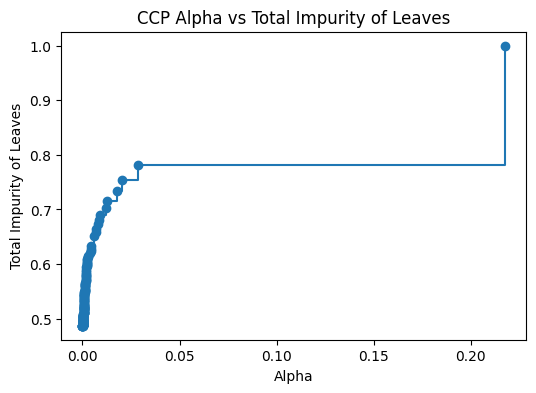

/tmp/ipython-input-3439321488.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LogImportance', y='Feature', data=feature_importance, palette="viridis")


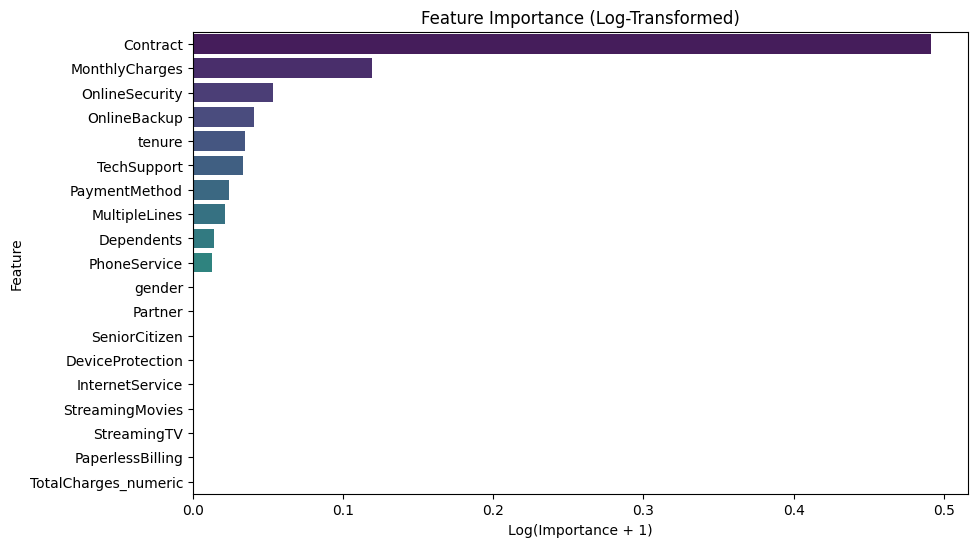

F1-scores for each fold: [0.81178593 0.81542056 0.80612846 0.81887906 0.81769912]
Mean F1-score (CV): 0.8139826245749513

--- Train Evaluation ---

Accuracy: 0.7919, Recall: 0.7830, Precision: 0.7971, F1-score: 0.7900
ROC Score (Discrete): 0.7919, AUC Score (Probabilities): 0.8697

Classification Report:
               precision    recall  f1-score   support

           0     0.7868    0.8007    0.7937      4139
           1     0.7971    0.7830    0.7900      4139

    accuracy                         0.7919      8278
   macro avg     0.7919    0.7919    0.7918      8278
weighted avg     0.7919    0.7919    0.7918      8278


--- Test Evaluation ---

Accuracy: 0.7700, Recall: 0.6818, Precision: 0.5543, F1-score: 0.6115
ROC Score (Discrete): 0.7419, AUC Score (Probabilities): 0.8148

Classification Report:
               precision    recall  f1-score   support

           0     0.8746    0.8019    0.8367      1035
           1     0.5543    0.6818    0.6115       374

    accuracy     

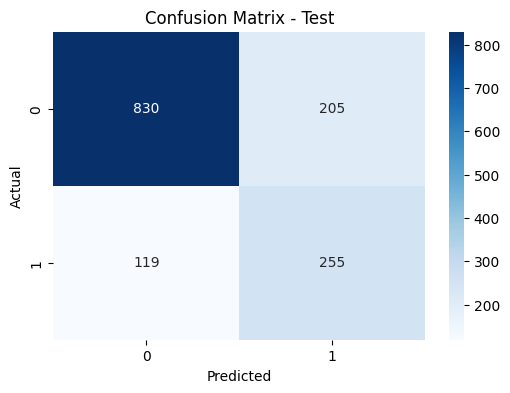

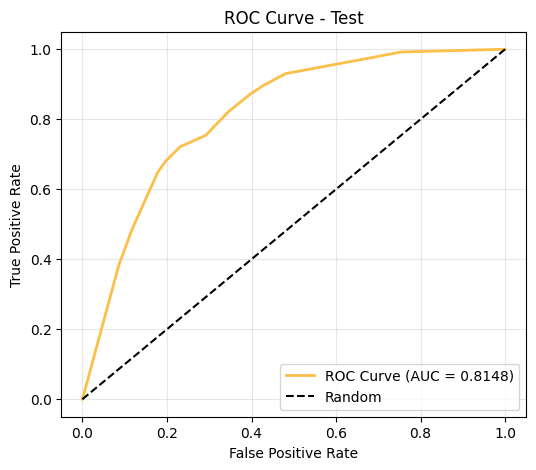

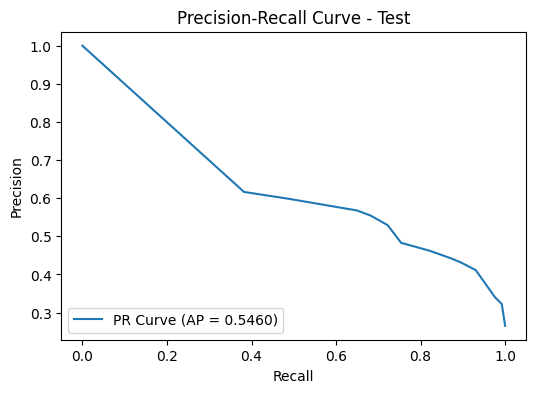

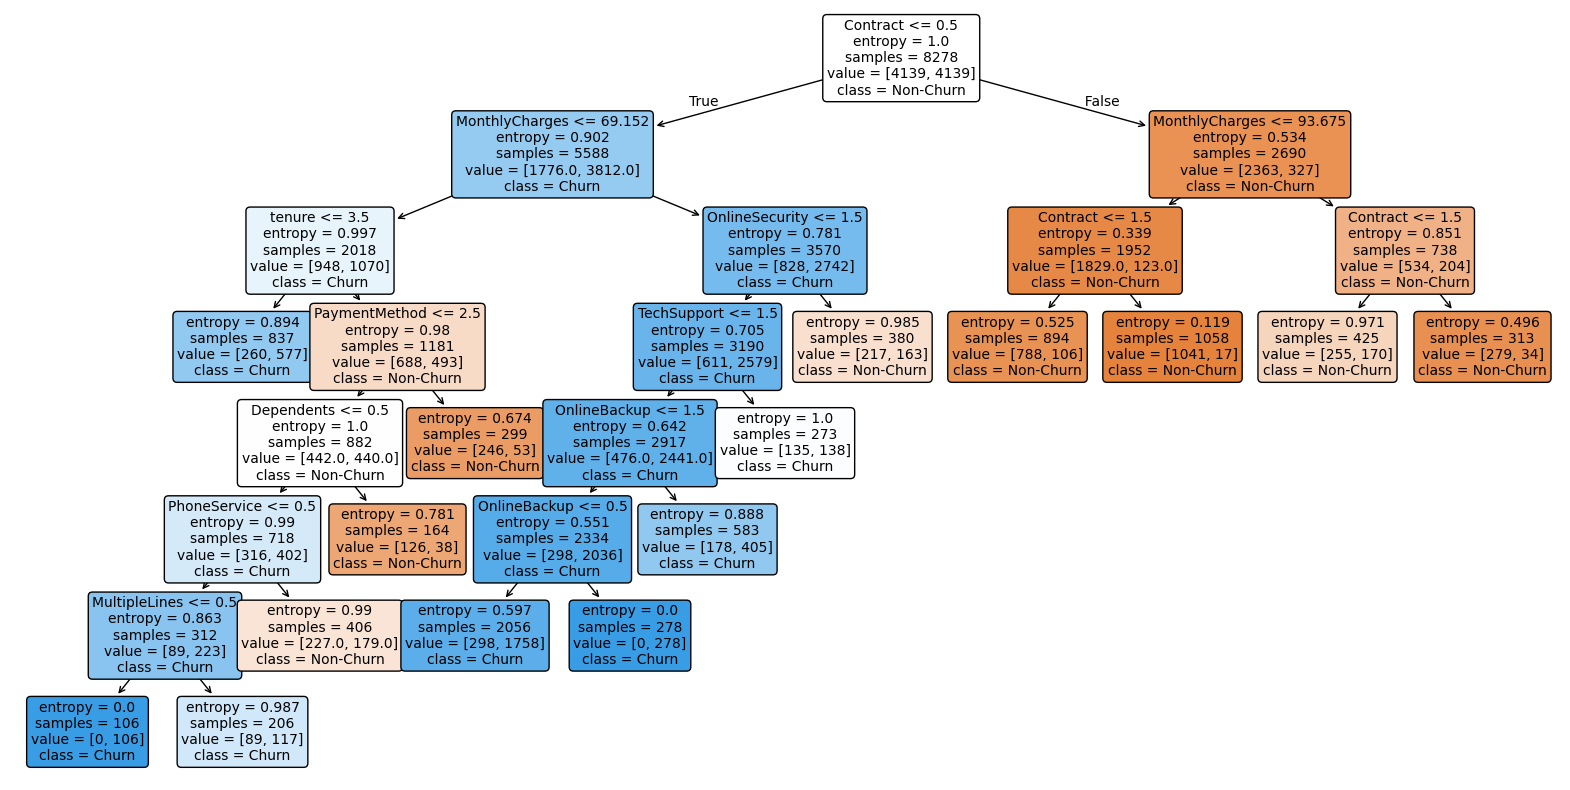

In [15]:
# Evaluation for full feature dataset
train_metrics1, test_metrics1 = evaluate_decision_tree_pipeline(
    dt_model1,
    X_train_res1,
    y_train_res1,
    X_test1,
    y_test1,
    best_thresh1,
    cv_splits=5,
    grid_search_estimator=grid1.best_estimator_
)

# Model After Feature Selection

Split X and Y add SMOTE

In [16]:
# For refined dataset after dropping zero-importance features
zero_features = ['gender', 'Partner', 'SeniorCitizen', 'DeviceProtection',
                 'InternetService', 'PaperlessBilling', 'StreamingMovies',
                 'StreamingTV']
X_train_res2, X_test2, y_train_res2, y_test2 = split_and_apply_smote(df_dt_2, zero_importance_features=zero_features)

X_train shape: (8278, 11)
X_test shape: (1409, 11)
y_train distribution after SMOTE:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Perform GridSearch

In [17]:
# For refined dataset
best_dt2, grid2 = decision_tree_grid_search(X_train_res2, y_train_res2)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best F1 Score (CV): 0.8148681661814727


Train Model

In [18]:
# Train model for refined dataset
dt_model2, best_thresh2, dt_train_prob2, dt_train_pred2, dt_test_prob2 = train_decision_tree(
    X_train_res2, y_train_res2, X_test2, y_test2
)
print ("Threshold Value:", best_thresh2)

Threshold Value: 0.4299999999999998


Evaluate Model


--- Overfitting/Underfitting Check ---
No major overfitting or underfitting detected


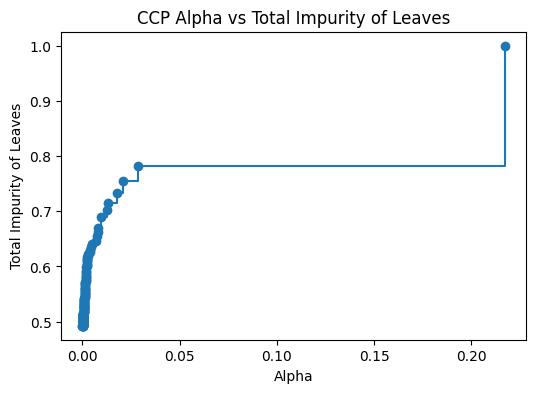

/tmp/ipython-input-3439321488.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LogImportance', y='Feature', data=feature_importance, palette="viridis")


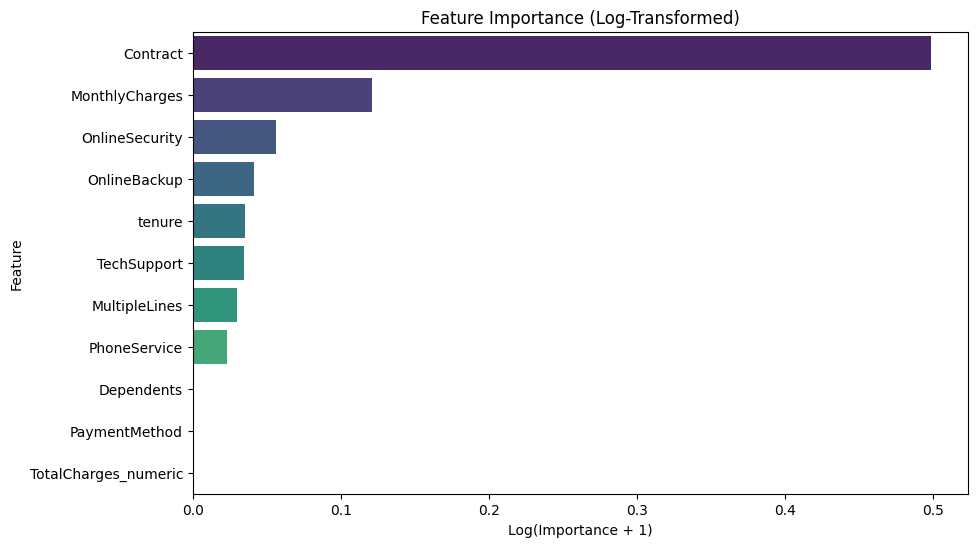

F1-scores for each fold: [0.81045752 0.81864696 0.81332567 0.81103286 0.82087782]
Mean F1-score (CV): 0.8148681661814727

--- Train Evaluation ---

Accuracy: 0.7876, Recall: 0.8265, Precision: 0.7669, F1-score: 0.7956
ROC Score (Discrete): 0.7876, AUC Score (Probabilities): 0.8668

Classification Report:
               precision    recall  f1-score   support

           0     0.8119    0.7487    0.7790      4139
           1     0.7669    0.8265    0.7956      4139

    accuracy                         0.7876      8278
   macro avg     0.7894    0.7876    0.7873      8278
weighted avg     0.7894    0.7876    0.7873      8278


--- Test Evaluation ---

Accuracy: 0.7480, Recall: 0.7353, Precision: 0.5179, F1-score: 0.6077
ROC Score (Discrete): 0.7440, AUC Score (Probabilities): 0.8167

Classification Report:
               precision    recall  f1-score   support

           0     0.8872    0.7527    0.8144      1035
           1     0.5179    0.7353    0.6077       374

    accuracy     

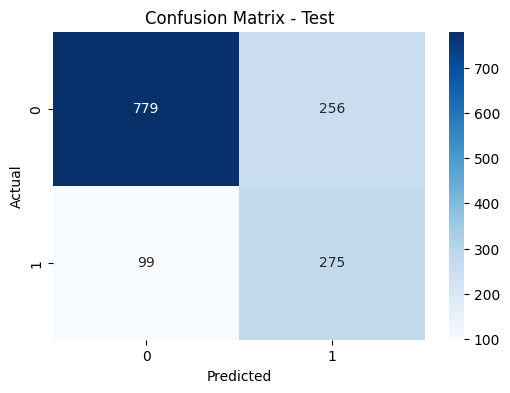

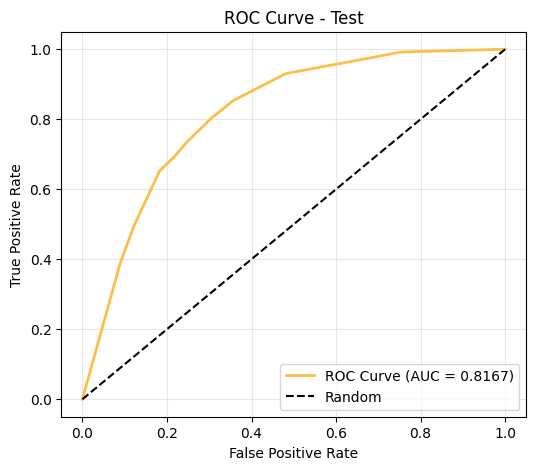

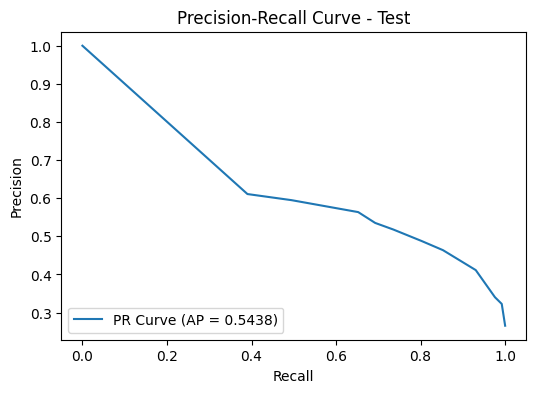

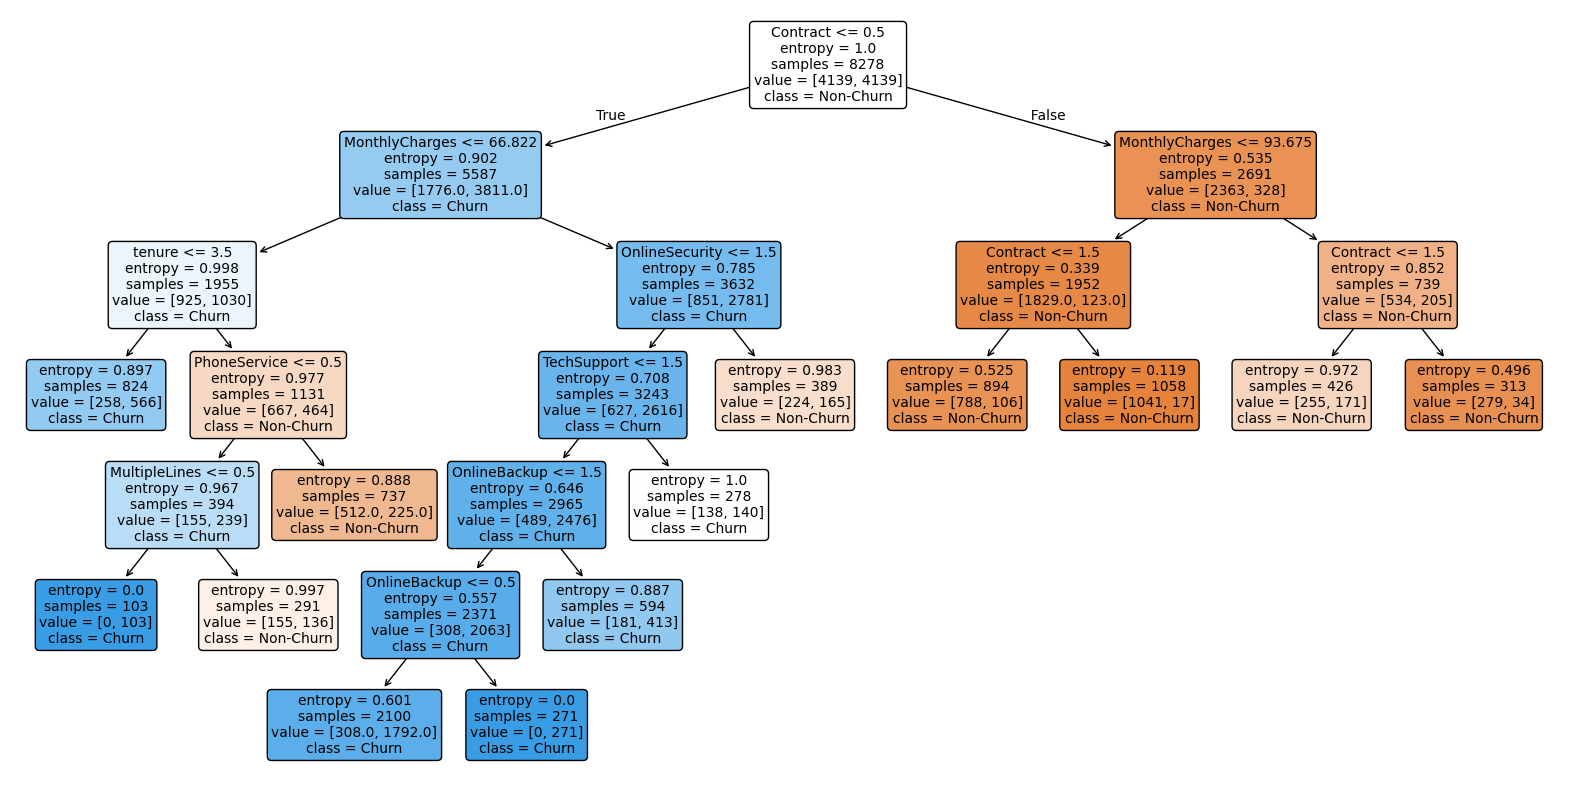

In [19]:
# Evaluation for refined feature dataset
train_metrics2, test_metrics2 = evaluate_decision_tree_pipeline(
    dt_model2,
    X_train_res2,
    y_train_res2,
    X_test2,
    y_test2,
    best_thresh2,
    cv_splits=5,
    grid_search_estimator=grid2.best_estimator_
)

# Save the Best Performing Model

In [20]:
import joblib

# Save the trained model
model_path = '/content/drive/MyDrive/DT_Model/dt_model_final.pkl'
joblib.dump(dt_model2, model_path)
print(f"Decision Tree model saved at: {model_path}")

# Save the best threshold found during tuning
threshold_path = '/content/drive/MyDrive/DT_Model/best_threshold.pkl'
joblib.dump(best_thresh2, threshold_path)
print(f"Best threshold saved at: {threshold_path}")

Decision Tree model saved at: /content/drive/MyDrive/DT_Model/dt_model_final.pkl
Best threshold saved at: /content/drive/MyDrive/DT_Model/best_threshold.pkl


In [ ]:
# Load the saved model and threshold
import joblib
model_path = '/content/drive/MyDrive/DT_Model/dt_model_final.pkl'
threshold_path = '/content/drive/MyDrive/DT_Model/best_threshold.pkl'

dt_model = joblib.load(model_path)
best_threshold = joblib.load(threshold_path)

print("Model and threshold loaded successfully!")